# Cross-Validation: Model Selection (3x3 Grid)

LOO-CV results for all 9 combinations of **transform** (none, log, normal_score) x **variogram model** (spherical, exponential, gaussian), evaluated on the full 1961-2023 record.

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RESULTS_DIR = "../../results"

with open(f"{RESULTS_DIR}/cross_validation/cv_results.pkl", "rb") as f:
    cv_raw = pickle.load(f)

rows = []
for (transform, model), metrics in sorted(cv_raw.items()):
    rows.append({
        "transform": transform,
        "model": model,
        "CRPS_mm": metrics["crps_mm"],
        "MAE_mm": metrics["mae_mm"],
        "CRPS_z": metrics["crps_z"],
        "n": metrics["n"],
    })

df = pd.DataFrame(rows).sort_values("CRPS_mm").reset_index(drop=True)

best = df.iloc[0]
print(f"Best: {best['transform']} + {best['model']}  "
      f"(CRPS_mm={best['CRPS_mm']:.4f}, MAE={best['MAE_mm']:.3f}, "
      f"n={best['n']:,})")
print()
df

Best: none + exponential  (CRPS_mm=0.7981, MAE=0.944, n=20,378,022)



,transform,model,CRPS_mm,MAE_mm,CRPS_z,n
0,none,exponential,0.798056,0.944379,0.014376,20378022
1,normal_score,exponential,0.853803,1.006185,0.219901,21742061
2,log,exponential,0.857296,1.002882,0.207933,21742022
3,normal_score,spherical,0.927471,1.093012,0.234934,21730926
4,none,spherical,0.933988,1.004414,0.017193,19338593
5,log,spherical,0.938915,1.096742,0.223961,21715153
6,normal_score,gaussian,1.027200,1.258904,0.257402,21464083
7,log,gaussian,1.041665,1.267623,0.246754,21285894
8,none,gaussian,1.076762,1.228891,0.019768,16689332


## Summary by variogram model

In [2]:
print("Average across transforms:")
print(df.groupby("model")[["CRPS_mm", "MAE_mm"]].mean()
      .sort_values("CRPS_mm").round(4).to_string())
print()
print("Average across variogram models:")
print(df.groupby("transform")[["CRPS_mm", "MAE_mm"]].mean()
      .sort_values("CRPS_mm").round(4).to_string())

Average across transforms:
             CRPS_mm  MAE_mm
model                       
exponential   0.8364  0.9845
spherical     0.9335  1.0647
gaussian      1.0485  1.2518

Average across variogram models:
              CRPS_mm  MAE_mm
transform                    
normal_score   0.9362  1.1194
none           0.9363  1.0592
log            0.9460  1.1224


## Heatmaps: CRPS and MAE across all 9 configurations

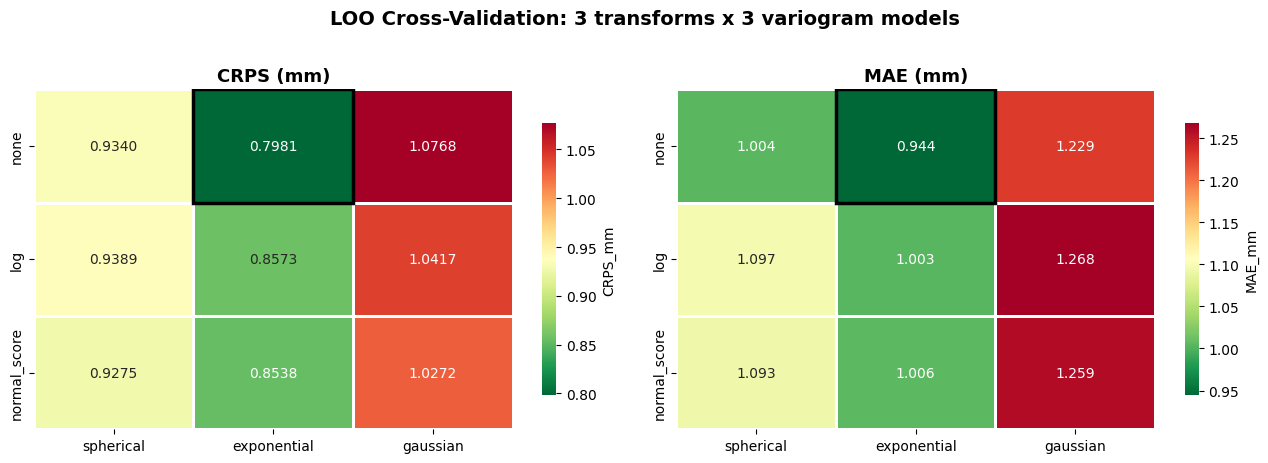

In [3]:
TRANSFORMS = ["none", "log", "normal_score"]
MODELS = ["spherical", "exponential", "gaussian"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, metric, title, fmt in [
    (axes[0], "CRPS_mm", "CRPS (mm)", ".4f"),
    (axes[1], "MAE_mm", "MAE (mm)", ".3f"),
]:
    pivot = df.pivot(index="transform", columns="model", values=metric)
    pivot = pivot.reindex(index=TRANSFORMS, columns=MODELS)

    best_val = pivot.min().min()
    sns.heatmap(
        pivot, annot=True, fmt=fmt, cmap="RdYlGn_r",
        linewidths=1, linecolor="white", ax=ax,
        cbar_kws={"label": metric, "shrink": 0.8},
    )
    for i in range(len(TRANSFORMS)):
        for j in range(len(MODELS)):
            if abs(pivot.iloc[i, j] - best_val) < 1e-6:
                ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=False,
                             edgecolor="black", lw=2.5))
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_ylabel("")
    ax.set_xlabel("")

fig.suptitle("LOO Cross-Validation: 3 transforms x 3 variogram models",
             fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.savefig("../../images/cv_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## Ranking: all 9 combinations by CRPS_mm

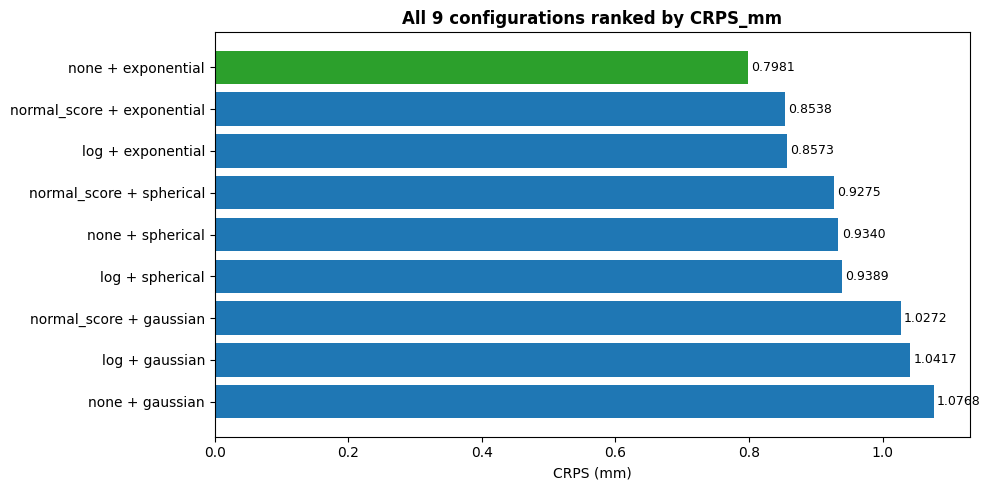

In [4]:
df_ranked = df.sort_values("CRPS_mm", ascending=True).reset_index(drop=True)
labels = [f"{r['transform']} + {r['model']}" for _, r in df_ranked.iterrows()]
colors = ["tab:green" if i == 0 else "tab:blue" for i in range(len(df_ranked))]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(labels[::-1], df_ranked["CRPS_mm"][::-1], color=colors[::-1])
ax.set_xlabel("CRPS (mm)")
ax.set_title("All 9 configurations ranked by CRPS_mm", fontweight="bold")

for bar, val in zip(bars, df_ranked["CRPS_mm"][::-1]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}", va="center", fontsize=9)

fig.tight_layout()
plt.savefig("../../images/cv_ranking.png", dpi=150, bbox_inches="tight")
plt.show()

## Key finding

The **exponential** variogram model consistently outperforms spherical and gaussian across all three transforms. Among transforms, **no transformation** yields the lowest CRPS_mm (0.7981), followed by normal_score (0.8538) and log (0.8573). The gaussian model performs worst in every case, likely due to its parabolic behavior near the origin which over-smooths short-range precipitation variability.

Selected configuration for all downstream analyses: **none + exponential** (CRPS_mm = 0.7981, MAE = 0.944 mm, n = 20,378,022 LOO predictions).